In [719]:
import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import itertools
from scipy.linalg import lstsq, null_space
from numpy.random import rand

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square, extent

from blochK.observable import (
    exp_value_O,
    conductivity_orbital_resolved,
    local_dos_QPI,
    find_Gamma,
)

import blochK

# from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D
# from alter_surf.utils3D import projector2layer


# latex style
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Palatino"],
    }
)

In [720]:
t_values = {
    (0, 0): np.array([0.0, 0.0, 0.0, 0.0]),
    (1, 0): np.array([1.0, 0.0, 0.0, 0.0]),
    (0, 1): np.array([1.0, 0.0, 0.0, 0.0]),
}

v, l = t_values_to_vector(t_values)

t2 = vector_to_t_values(v, l)

assert all(np.allclose(t_values[k], t2[k]) for k in t_values)

In [721]:
pauli_vector = np.array(
    [
        np.array([[1, 0], [0, 1]]),  # identity
        np.array([[0, 1], [1, 0]]),  # sigma x
        np.array([[0, -1j], [1j, 0]]),  # sigma y
        np.array([[1, 0], [0, -1]]),  # sigma z
    ]
)


def d_matrix(d_vector):
    """generates a 2x2 matrix of the form
    x_0 sigma_0 + d_x sigma_x + d_y sigma_y + d_z sigma_z
    """

    return np.sum(d_vector[:, None, None] * pauli_vector, axis=0)


def two_band_slab_hamiltonian(
    kx: np.ndarray, ky: np.ndarray, t_values: dict, len_z=20, open_bcs_z=True
) -> np.ndarray:
    """Generates an arbitrary 3D slab Hamiltonian based on a dictionary specifying the d-values
    for hoppings in arbitrary directions.

    Args:
        kx (np.ndarray): List of kx values
        ky (np.ndarray): List of ky values
        t_values (dict): a dictionary of every lattiCe vector and the associated (complex)
            d vector for it
        len_z (int, optional): number of layers in the z-direction. Defaults to 20.
        open_bcs_z (bool, optional): Open or closed boundary conditions. Defaults to True.

    Returns:
        np.ndarray: An array of Hamiltonians
    """

    hk = np.zeros((2 * len_z, 2 * len_z, *kx.shape), dtype=complex)

    # add each set of hoppings
    for hopping in t_values:

        d_mat = d_matrix(t_values[hopping])  # hopping matrix

        # the (0,0,0) component has no hermitian conjugate
        # so must be real and will be doubledlater, let's half it
        if hopping == (0, 0, 0):
            d_mat = d_mat / 2

        phases = np.exp(-1j * kx * hopping[0] - 1j * ky * hopping[1])  # phases

        term_to_add = phases[:, None, None] * d_mat  #

        ind1 = np.arange(len_z)
        ind2 = np.arange(len_z) + hopping[2]
        if open_bcs_z:  # either assign only hoppings that don't cross the boundary
            ind1 = ind1[(ind2 < len_z) * (ind2 >= 0)]
            ind2 = ind2[(ind2 < len_z) * (ind2 >= 0)]
        else:  # or wrap around the periodic boundaries
            ind2 = ind2 % len_z

        # add the hoppings in
        hk[2 * ind1, 2 * ind2] += term_to_add[:, 0, 0]
        hk[2 * ind1 + 1, 2 * ind2] += term_to_add[:, 1, 0]
        hk[2 * ind1, 2 * ind2 + 1] += term_to_add[:, 0, 1]
        hk[2 * ind1 + 1, 2 * ind2 + 1] += term_to_add[:, 1, 1]

    # add hermitian conjugate
    return hk + np.moveaxis(hk, 1, 0).conj()


def d_vector(t_values, k_vals):
    """Computes the d-vector at each k-point given a dictionary of hopping terms
    Args:
        t_values (dict): a dictionary of every lattice vector and the associated (complex)
            Pauli vector for it
        k_vals (np.ndarray): array of k-values (shape (N, 3))
    Returns:
        np.ndarray: d-vectors at each k-point
    """

    d_vec = np.zeros((4, len(k_vals)))

    for hopping in t_values:
        phase = np.exp(1j * np.sum(k_vals * np.array(hopping), axis=1))
        values = t_values[hopping][:, None] * phase[None, :]
        d_vec += values.real * 2

    return d_vec

In [ ]:
# constraints take the form (position, derivative, value),
# where the position is where in k-space the constraint is applied, (3-vector)
# the derivative is a vector indicating which derivative to apply (e.g., [1,0,0] for d/dkx), (3-vector)
# and the value is the desired value of the Pauli vector at that point (4-vector)


def constraints_from_weyl_node(weyl_pos, chirality):
    """Returns the constraints that place a Weyl node of the form
    chirality * sigma . k around the specified weyl position.

    Args:
        weyl_pos (tuple): the position of the Weyl node
        chirality (float): the chirality of the Weyl node

    Returns:
        set: The constraints in the form {(position, derivative, value)}
    """

    weyl_pos = tuple(weyl_pos)
    zero_order = weyl_pos, (0, 0, 0), (0, 0, 0, 0)
    x_deriv = weyl_pos, (1, 0, 0), (0, chirality, 0, 0)
    y_deriv = weyl_pos, (0, 1, 0), (0, 0, chirality, 0)
    z_deriv = weyl_pos, (0, 0, 1), (0, 0, 0, chirality)
    return {zero_order, x_deriv, y_deriv, z_deriv}


# two functions that transform between t_values dict and a vector representation
def t_values_to_vector(t_values):
    """Transforms a dictionary of t_values into a vector
    representation of the real and imaginary parts. The (0,0,0) hopping
    only has real parts, so contributes 4 elements, while other hoppings
    contribute 8 elements (real and imaginary parts).

    Args:
        t_values (dict): a dictionary of every lattice vector and the associated (complex)
            d vector for it
    Returns:
        np.ndarray: vector representation
        list: list of hoppings in order, ensures consistent ordering
    """

    hoppings_list = sorted(t_values.keys())
    vector = []
    for hopping in hoppings_list:
        # if all(v == 0 for v in hopping):
        if False:
            vector.extend(t_values[hopping].real)
        else:
            vector.extend(t_values[hopping].real)
            vector.extend(t_values[hopping].imag)
    return np.array(vector), hoppings_list


def vector_to_t_values(vector, hoppings_list):
    """Transforms a vector representation of t_values back into a dictionary.
    Args:
        vector (np.ndarray): vector representation
        hoppings_list (list): list of hoppings in order
    Returns:
        dict: t_values dictionary
    """
    hoppings_list = sorted(hoppings_list)
    t_values = {}
    i = 0
    for hopping in hoppings_list:
        if False:
            # if all(v == 0 for v in hopping):
            real_part = vector[i : i + 4]
            t_values[hopping] = real_part
            i += 4
            continue
        else:
            real_part = vector[i : i + 4]
            imag_part = vector[i + 4 : i + 8]
            t_values[hopping] = real_part + 1j * imag_part
            i += 8
    return t_values


def _derivative_factor(position, derivative, hopping):
    # computes the factor arising from applying the derivative operator
    # to the exponential term e^{-i k . r}
    expo = np.exp(-1j * (np.dot(position, hopping)))
    prefactor = 1
    for dim in range(3):
        prefactor *= (-1j * hopping[dim]) ** (derivative[dim])
    return prefactor * expo


def constraint_as_matrix_entry(constraint, hoppings_list):
    """Given a single constraint, of the form (position, derivative, value),
    which sets an arbitrary derivative of the d-vector at a position to a value.
    Args:
        constraint (tuple): (position, derivative, value), with
            position (3-vector): k-point where the constraint is applied
            derivative (3-vector): which derivative to apply
            value (4-vector): desired value of the d-vector at that point
        hoppings_list (list): list of hoppings in order
    Returns:
        np.ndarray: matrix row corresponding to the constraint
        np.ndarray: value vector corresponding to the constraint
    """
    hoppings_list = sorted(hoppings_list)
    position, derivative, value = constraint

    factors = {}
    for hopping in hoppings_list:
        factor = _derivative_factor(position, derivative, hopping)
        factors[hopping] = factor

    rows = []
    for j in range(4):
        factor_j = {
            hopping: factors[hopping] * np.eye(4)[j] for hopping in hoppings_list
        }
        r, keys = t_values_to_vector(factor_j)
        rows.append(r)

        # make sure the keys are still in the same order
        assert keys == hoppings_list

    return np.array(rows), value


def total_matrix_from_constraints(constraints, hoppings_list):
    """Given a set of constraints, builds the total constraint matrix
    and value vector. These can then be used to solve for the t_values vector
    that satisfies all constraints.
    Args:
        constraints (set): set of constraints, each of the form
            (position, derivative, value)
        hoppings_list (list): list of hoppings in order
    Returns:
        np.ndarray: total constraint matrix
        np.ndarray: total value vector
    """
    hoppings_list = sorted(hoppings_list)
    rows = []
    values = []
    for constraint in constraints:
        row, value = constraint_as_matrix_entry(constraint, hoppings_list)
        rows.append(row)
        values.extend(value)
    return np.vstack(rows), np.array(values)


def solve_constraint_matrix(matrix, value_vector):
    """Solves the constraint matrix equation Ax = b, where A is the
    constraint matrix, x is the vector of t_values, and b is the value vector.
    Args:
        matrix (np.ndarray): constraint matrix
        value_vector (np.ndarray): value vector
    Returns:
        np.ndarray: solution vector
        np.ndarray: basis for the null space of the constraint matrix
    """

    rankA = np.linalg.matrix_rank(matrix)
    rankAug = np.linalg.matrix_rank(np.column_stack([matrix, value_vector]))

    print(rankA, rankAug)

    if rankA < rankAug:
        print(
            "\nSystem is inconsistent (no solution).\nToo many constraints and not enough hoppings?"
        )
        # return None

    sol, residuals, _, _ = lstsq(matrix, value_vector)
    assert residuals.size == 0

    null_basis = null_space(matrix)
    return sol, null_basis

24 25

System is inconsistent (no solution).
Too many constraints and not enough hoppings?


In [ ]:
allowed_hoppings = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
    # (0, 0, 2),
]


c1 = constraints_from_weyl_node((0, 0, 0), 1)
c2 = constraints_from_weyl_node((0.5, 0.5, 0), -1)

c = c1 | c2

m, v = total_matrix_from_constraints(c, allowed_hoppings)

sol, null_vecs = solve_constraint_matrix(m, v)


coeffs = np.random.randn(null_vecs.shape[1]) * 5
x_rand = sol + null_vecs @ coeffs

t_out = vector_to_t_values(x_rand, allowed_hoppings)

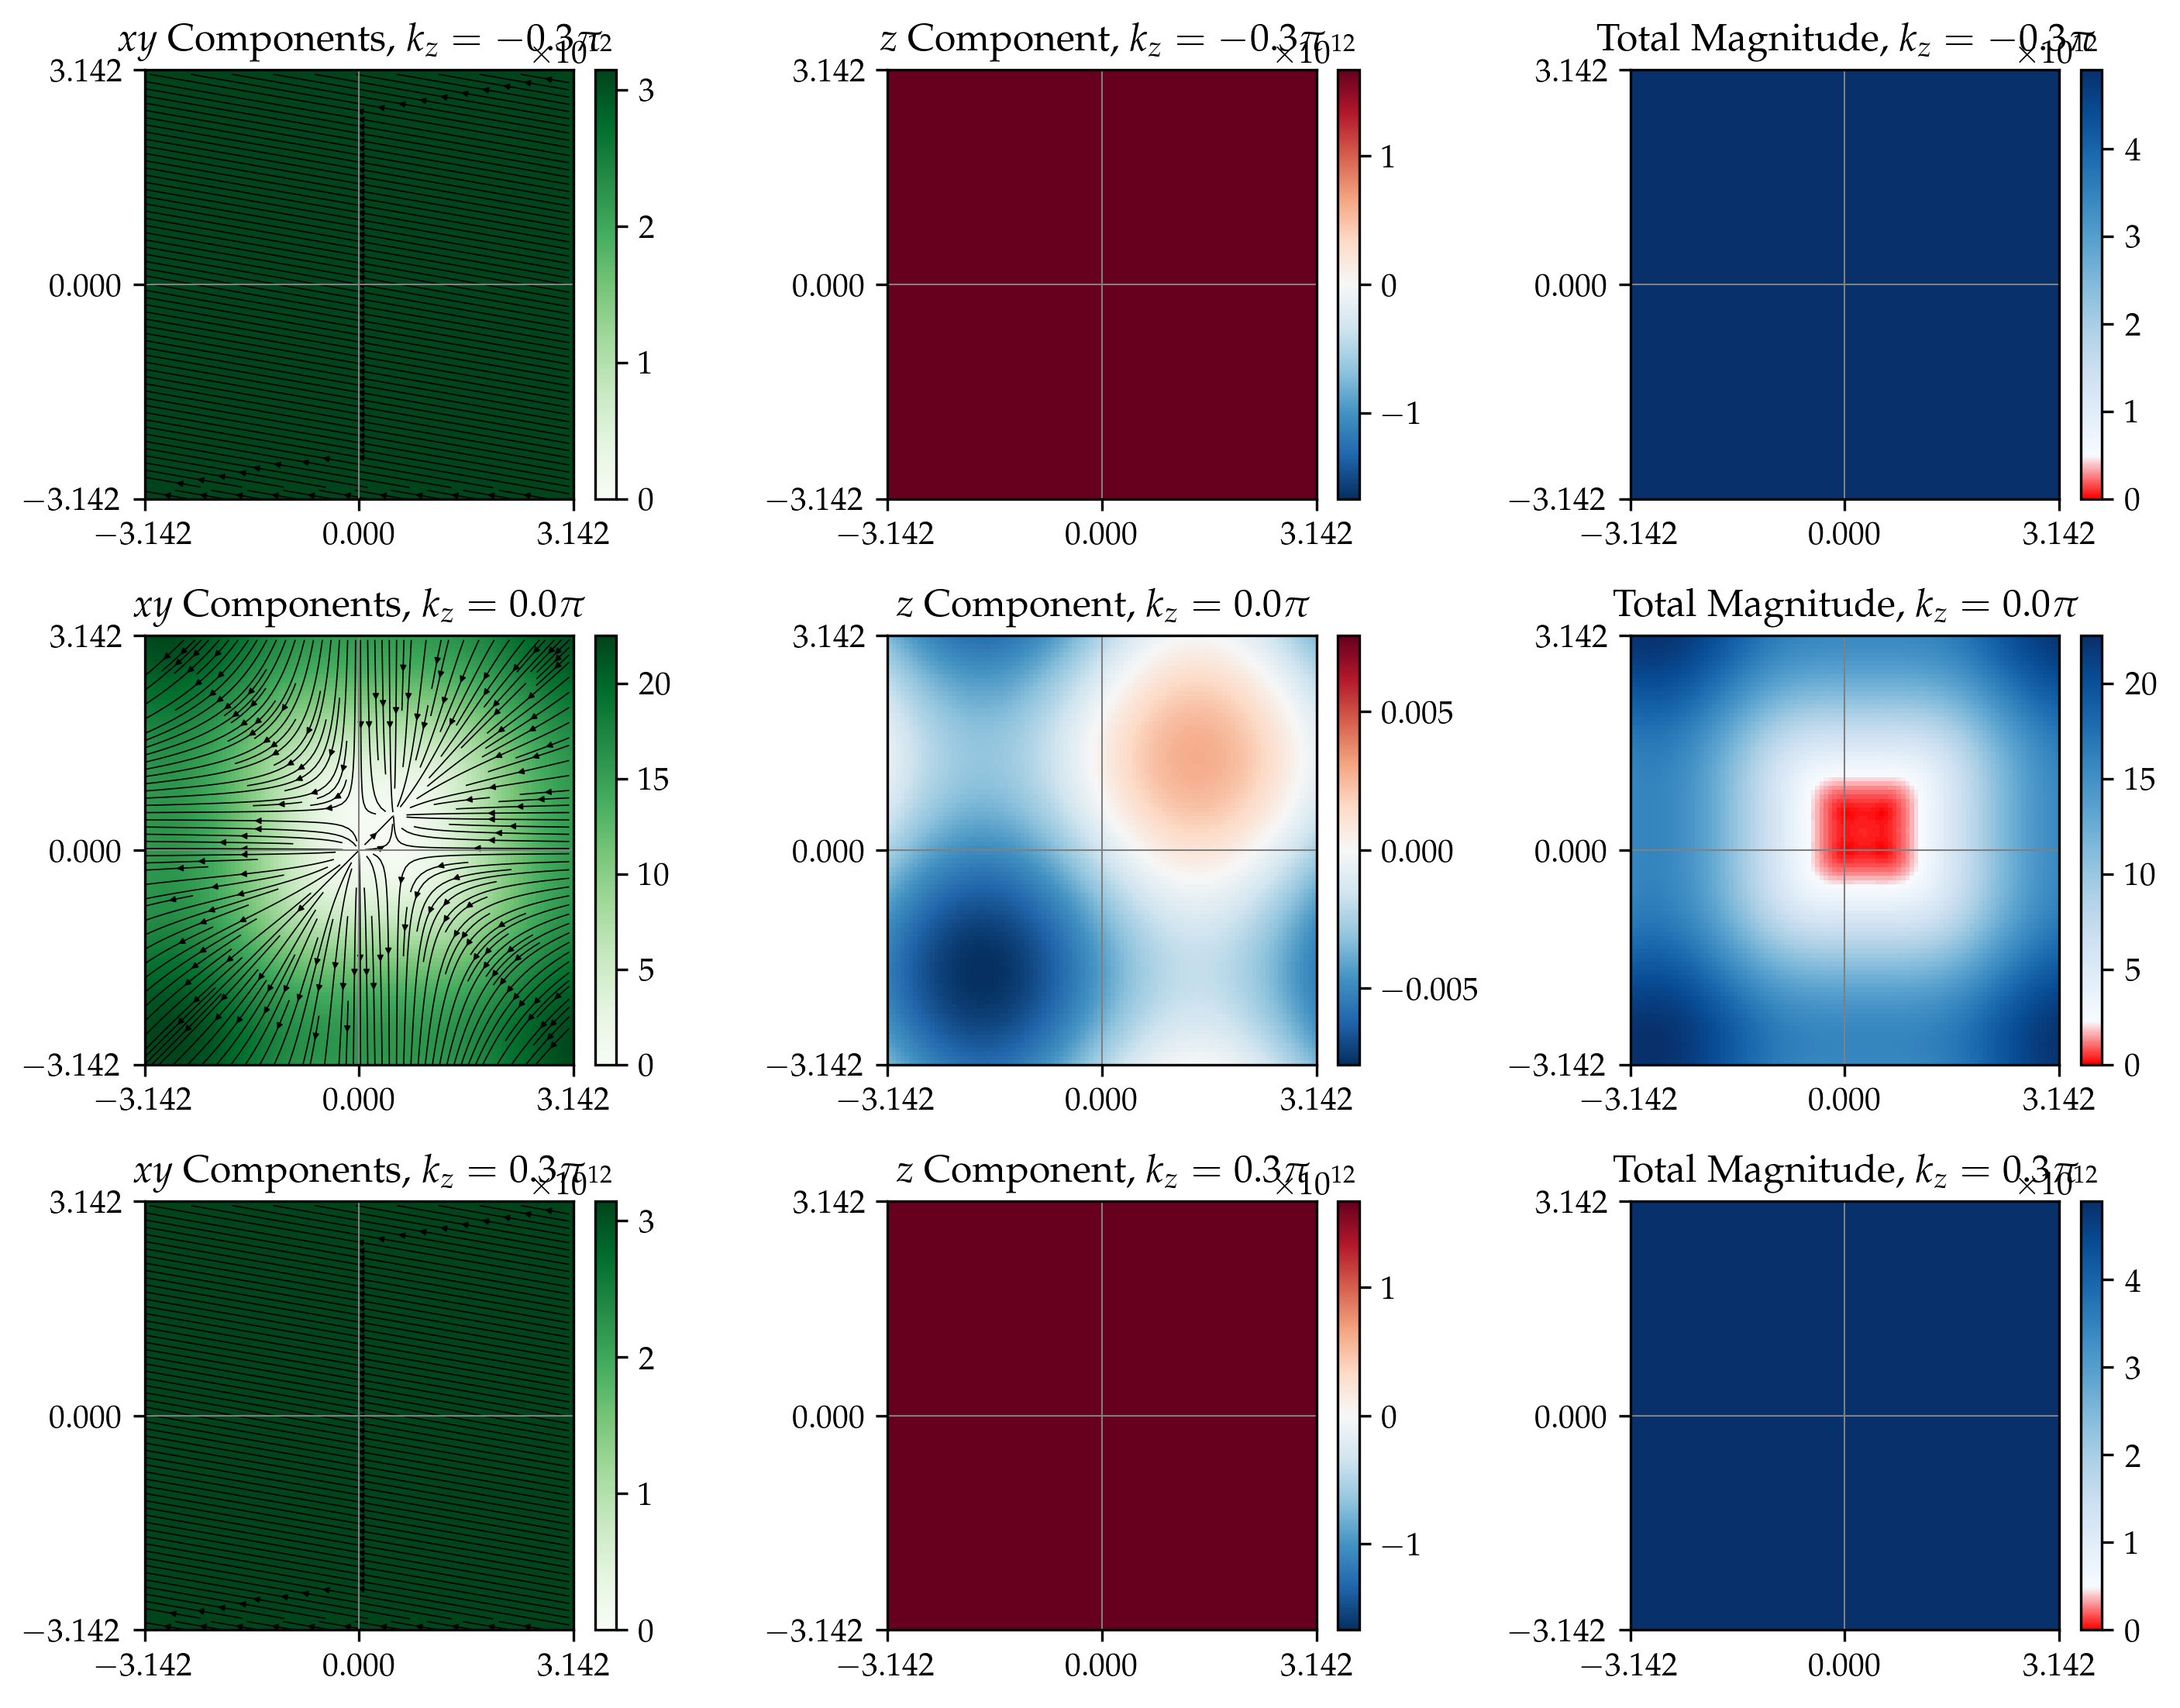

In [ ]:
extent = (-np.pi, np.pi)

k_vals = np.linspace(extent[0], extent[1], 100, endpoint=False)
KX, KY = np.meshgrid(k_vals, k_vals)
kz_values = np.linspace(-0.3, 0.3, 3, endpoint=True)

# document_width in mm
document_width = 240
figwidth = document_width / 25.4
figheight = len(kz_values) * figwidth / 3 - 2


fig, axes = plt.subplots(
    len(kz_values), 3, figsize=(document_width / 25.4, figheight), dpi=300
)

for j, kz in enumerate(kz_values):

    d_values = np.array(
        [
            d_vector(t_out, np.array([[kx, ky, kz * np.pi]]))
            for kx, ky in zip(np.ravel(KX), np.ravel(KY))
        ]
    )
    D0 = d_values[:, 0].reshape(KX.shape)
    DX = d_values[:, 1].reshape(KX.shape)
    DY = d_values[:, 2].reshape(KX.shape)
    DZ = d_values[:, 3].reshape(KX.shape)
    mag = np.sqrt(D0**2 + DX**2 + DY**2 + DZ**2)
    mags_xy = np.sqrt(DX**2 + DY**2)

    ax = axes[j]

    im = ax[0].streamplot(
        KX, KY, DX, DY, color="black", linewidth=0.4, density=2, arrowsize=0.4
    )
    im_mag = ax[0].imshow(
        mags_xy,
        extent=(extent[0], extent[1], extent[0], extent[1]),
        origin="lower",
        cmap="Greens",
        vmin=0,
        vmax=np.max(mags_xy),
    )

    mag_z = ax[1].imshow(
        DZ,
        extent=(extent[0], extent[1], extent[0], extent[1]),
        origin="lower",
        cmap="RdBu_r",
        vmin=-np.max(np.abs(DZ)),
        vmax=np.max(np.abs(DZ)),
    )

    cvals = [0.0, *np.linspace(0.1 * np.max(mag), np.max(mag), 10)]
    blues = matplotlib.colormaps["Blues"]
    colors = [
        "red",
        *[blues(i) for i in np.linspace(0, 1, 10)],
    ]

    norm = plt.Normalize(min(cvals), max(cvals))
    tuples = list(zip(map(norm, cvals), colors))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

    mag_sum = ax[2].imshow(
        mag,
        extent=(extent[0], extent[1], extent[0], extent[1]),
        origin="lower",
        cmap=cmap,
        norm=norm,
    )

    # choose colourmap for cbar
    cbar1 = fig.colorbar(im_mag, ax=ax[0], fraction=0.046, pad=0.04)
    cbar2 = fig.colorbar(mag_z, ax=ax[1], fraction=0.046, pad=0.04)
    cbar3 = fig.colorbar(mag_sum, ax=ax[2], fraction=0.046, pad=0.04)

    ax[0].set_title(r"$xy$ Components, $k_z={:.1f}\pi$".format(kz))
    ax[1].set_title(r"$z$ Component, $k_z={:.1f}\pi$".format(kz))
    ax[2].set_title(r"Total Magnitude, $k_z={:.1f}\pi$".format(kz))

for ax in axes.flatten():
    ax.set_xticks([extent[0], 0, extent[1]])
    # ax.set_xticklabels([r"$-pi$", "0", r"$\pi$"])
    ax.set_yticks([extent[0], 0, extent[1]])
    # ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])

    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

plt.tight_layout()
# plt.savefig("d_vector_plots.png", dpi=300)